In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from TransferFunction import RFSoC
import numpy as np
import DPD
from SignalSource import OFDMSource
from cfr import hard_clip, soft_clip
import matplotlib.pyplot as plt
from scipy.signal import welch

# Uncomment for separate plot windows in Jupyter / IPython:
%matplotlib qt

if __name__ == '__main__':
    # =================================================================
    # 1. PARAMETERS
    # =================================================================
    NYQUIST_ZONE = 2   # Set to 1 or 2
    NUM_SAMPLES = 200_000
    bw = 196.608e6
    print(bw)


    # Initial connection
    rfsoc = RFSoC("192.168.3.1", num_samples=NUM_SAMPLES)

    print(f"--- Configuring RF front-end for Nyquist Zone {NYQUIST_ZONE} ---")
    
    if NYQUIST_ZONE == 1:
        power_dbm = 2.0          
        adc_attenuation = 8.0    
        dac_nco = 900.0         
        adc_nco = 900.0         
    elif NYQUIST_ZONE == 2:
        power_dbm = 4.5          
        adc_attenuation = 4.0    
        dac_nco = -1000.0        
        adc_nco = -1000.0        
    else:
        raise ValueError("Nyquist Zone must be 1 or 2.")

    # Configure hardware
    rfsoc.set_power_dBm(power_dbm)
    rfsoc.set_adc_attenuation(adc_attenuation)
    rfsoc.set_dac_nyquist_zone(NYQUIST_ZONE)
    rfsoc.set_dac_nco_frequency(dac_nco)
    rfsoc.set_adc_nyquist_zone(NYQUIST_ZONE)
    rfsoc.set_adc_nco_frequency(adc_nco)

    # =================================================================
    # 2. SIGNAL GENERATION
    # =================================================================
    fs = rfsoc.fs_dac
    ofdm = OFDMSource(bw=bw, N_samples=NUM_SAMPLES, fs=fs, mod_order=256)
    x = ofdm.generate(seed=42) * 0.85
    
    # x = hard_clip(x)
    # =================================================================
    # 3. DPD SETUP & MEASUREMENT 1 (WITHOUT DPD)
    # =================================================================
    GMP = DPD.GMP(Ka=11, La=20, Kb=0, Lb=0, Mb=0, Kc=0, Lc=0, Mc=0)

    ARVTDNN = DPD.ARVTDNN(
        L=20, 
        K=11,
        hidden_sizes=[512],  # One layer removed, parameters halved
        lr=4.35e-3,                # Slightly smaller learning rate
        epochs=120,             # More epochs to find the optimum
        activation='gelu',    # Modern activation function
        batch_size=128         # IMPORTANT: Smaller batch size (~24 steps per epoch)
    )
    
    y_raw = rfsoc.measure(x)

    linear_mask = np.abs(y_raw) < (0.3 * np.max(np.abs(y_raw)))
    
    # Compute gain from unsaturated (linear) samples only
    
    gain = np.sum(np.conj(x) * y_raw) / np.sum(np.conj(x) * x)
    
    y = y_raw / gain


    # =================================================================
    # 4. TRAINING & APPLICATION
    # =================================================================
    n_valid = int(NUM_SAMPLES * 0.5)

    GMP.train(y[:n_valid], x[:n_valid])
    ARVTDNN.train(y[:n_valid], x[:n_valid])

    x_dpd_gmp = hard_clip(GMP.apply(x))
    x_dpd_arvtdnn = hard_clip(ARVTDNN.apply(x))

    # =================================================================
    # 5. MEASUREMENT 2 (WITH DPD)
    # =================================================================
    y_gmp = rfsoc.measure(x_dpd_gmp) / gain
    y_arvtdnn = rfsoc.measure(x_dpd_arvtdnn) / gain

    rfsoc.close()

    # =================================================================
    # 6. SAVE DATA
    # =================================================================
    filename = f"messdaten_zone{NYQUIST_ZONE}.npz"
    np.savez(filename, 
             x=x, y=y, y_gmp=y_gmp, y_arvtdnn=y_arvtdnn, fs=fs, gain=gain,bw=bw,)
    print(f"Done! Data saved to: {filename}")

    # =================================================================
    # 7. QUICK-VERIFICATION DASHBOARD
    # =================================================================
    print("Creating verification plots...")
    
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f"Quick Verification - Nyquist Zone {NYQUIST_ZONE}", fontsize=16)

    # Signal dict for iteration
    signals = {'w/o DPD': (y, 'orange'), 'GMP': (y_gmp, 'blue'), 'ARVTDNN': (y_arvtdnn, 'green')}

    # --- Plot 1: AM/AM ---
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot([0, 1], [0, 1], color='black', linestyle='--', label="Ideal", zorder=10)
    for name, (sig, col) in signals.items():
        ax1.scatter(np.abs(x)/np.max(np.abs(1)), np.abs(sig)/np.max(np.abs(1)), s=1, alpha=0.5, color=col, label=name)
    ax1.set_title("AM/AM Characteristic")
    ax1.set_xlabel("|x|")
    ax1.set_ylabel("|y|")
    ax1.grid(True)
    ax1.legend()

    # --- Plot 2: AM/PM ---
    ax2 = fig.add_subplot(2, 2, 2)
    ax2.axhline(0, color='black', linestyle='--', label="Ideal", zorder=10)
    for name, (sig, col) in signals.items():
        phase_diff = np.angle(sig) - np.angle(x)
        phase_diff_deg = np.degrees((phase_diff + np.pi) % (2 * np.pi) - np.pi)
        ax2.scatter(np.abs(x), phase_diff_deg, s=1, alpha=0.5, color=col, label=name)
    ax2.set_title("AM/PM Characteristic")
    ax2.set_xlabel("|x|")
    ax2.set_ylabel("Phase Error (°)")
    ax2.set_ylim([-80, 80])
    ax2.grid(True)

    # --- Plot 3: Spectrum (Welch PSD) ---
    ax3 = fig.add_subplot(2, 2, 3)
    
    # Compute reference level from ideal signal
    f, Pxx_x = welch(x, fs, window='blackmanharris', nperseg=2048, return_onesided=False)
    Pxx_x_dB = 10 * np.log10(np.fft.fftshift(Pxx_x) + 1e-20)
    ref_level = np.max(Pxx_x_dB)
    f_shifted = np.fft.fftshift(f) / 1e6
    ax3.plot(f_shifted, Pxx_x_dB - ref_level, color='black', label='Ideal', zorder=10)

    for name, (sig, col) in signals.items():
        _, Pxx = welch(sig, fs, window='blackmanharris', nperseg=2048, return_onesided=False)
        Pxx_dB = 10 * np.log10(np.fft.fftshift(Pxx) + 1e-20)
        ax3.plot(f_shifted, Pxx_dB - ref_level, color=col, label=name, alpha=0.8)
        
    ax3.set_title("Spectrum (Normalized PSD)")
    ax3.set_xlabel("Frequency (MHz)")
    ax3.set_ylabel("dB")
    ax3.set_ylim([-60, 5])
    ax3.grid(True)

# --- Plot 4: Constellation (I/Q) ---
    ax4 = fig.add_subplot(2, 2, 4)
    
    # 1. FFT: Transform to frequency domain (subcarrier level)
    X_ideal = np.fft.fft(x)
    
    # 2. Find active bins (filters empty guard bands and DC)
    threshold = 1e-6 
    active_bins = np.abs(X_ideal) > threshold
    
    # 3. QAM normalization factor
    X_qam_ideal = X_ideal[active_bins]
    scale_factor = np.mean(np.abs(X_qam_ideal))
    X_qam_ideal = X_qam_ideal / scale_factor

    # Transform received signals to frequency domain and plot
    for name, (sig, col) in signals.items():
        SIG_fft = np.fft.fft(sig)
        SIG_qam = SIG_fft[active_bins] / scale_factor
        
        # rasterized=True keeps SVG file size small
        ax4.scatter(np.real(SIG_qam), np.imag(SIG_qam), s=2, alpha=0.5, color=col, label=name, rasterized=True)
        
    # Overlay ideal constellation on top
    ax4.scatter(np.real(X_qam_ideal), np.imag(X_qam_ideal), s=4, color='black', marker='x', label='Ideal', zorder=10, rasterized=True)
    
    ax4.set_title("Demodulated QAM (Frequency Domain)")
    ax4.set_xlabel("In-Phase (I)")
    ax4.set_ylabel("Quadrature (Q)")
    ax4.axis('equal')  # Keep aspect ratio square
    ax4.grid(True)
    
    ax4.set_xlim([-2.5, 2.5])
    ax4.set_ylim([-2.5, 2.5])

    plt.tight_layout()
    plt.show()
    print(np.max(np.abs(y_raw)))

196608000.0
--- Konfiguriere RF-Frontend für Nyquist-Zone 2 ---
DAC Current → 31981 µA
Target 4.5 dBm → VOP = 31981.25 µA → actual ≈ 4.5 dBm
ADC Attenuation → 0.0 dB
DAC Nyquist Zone → 2
DAC NCO Frequency → -1000.0 MHz
ADC Nyquist Zone → 2
ADC NCO Frequency → -1000.0 MHz
Fertig! Daten sicher gespeichert in: messdaten_zone2.npz
Erstelle Überprüfungs-Plots...
0.5002122682365616


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Saved: Plot_AM_AM_PM.svg
Saved: Plot_Spectrum.svg
Saved: Plot_Constellation.svg


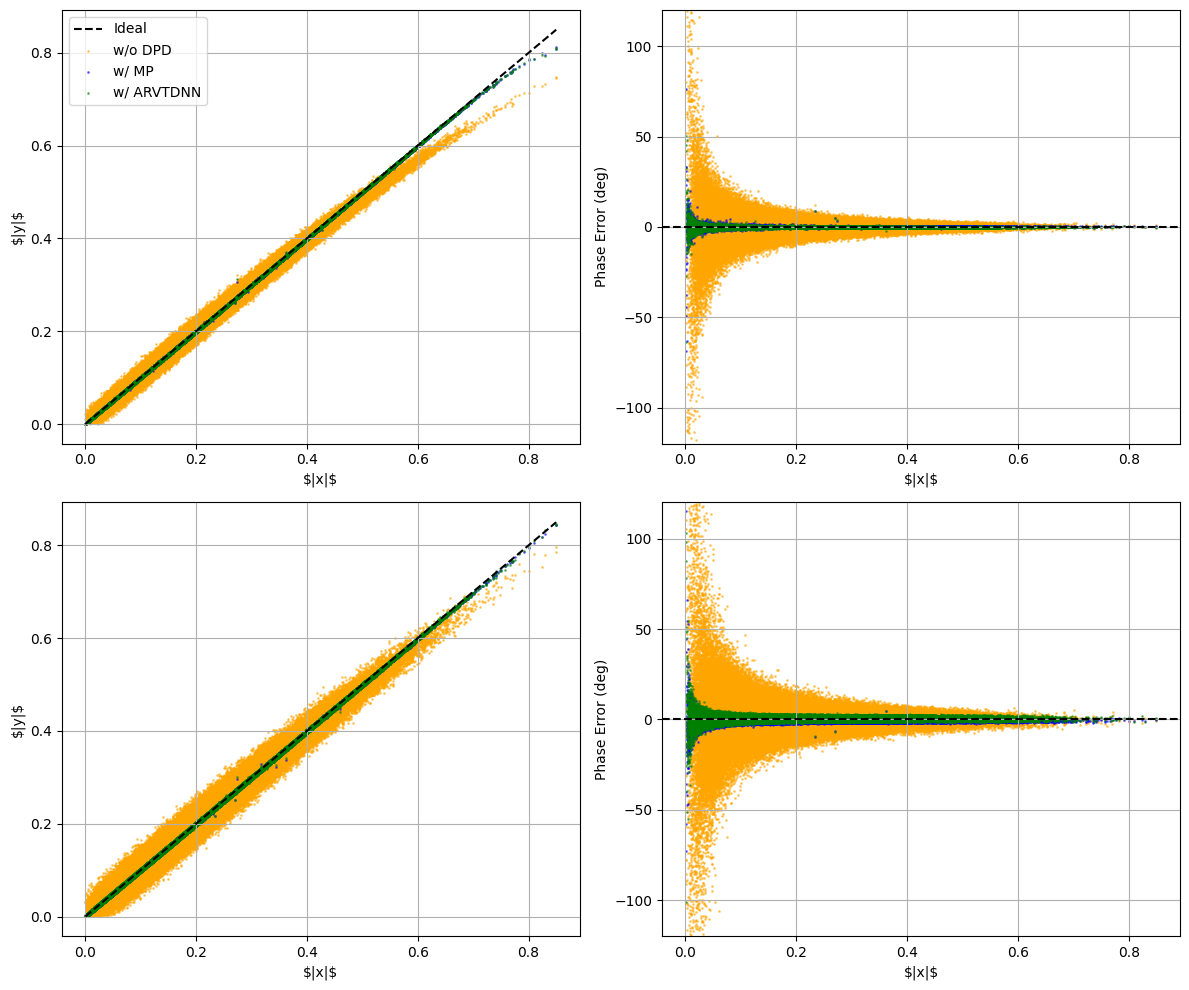

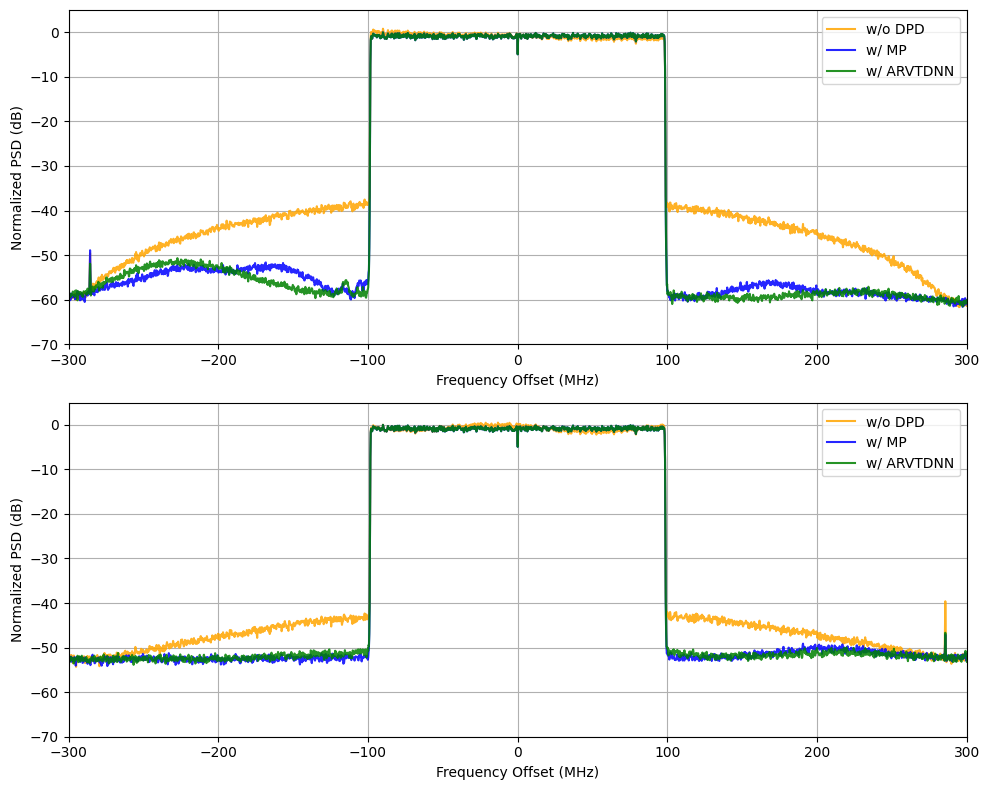

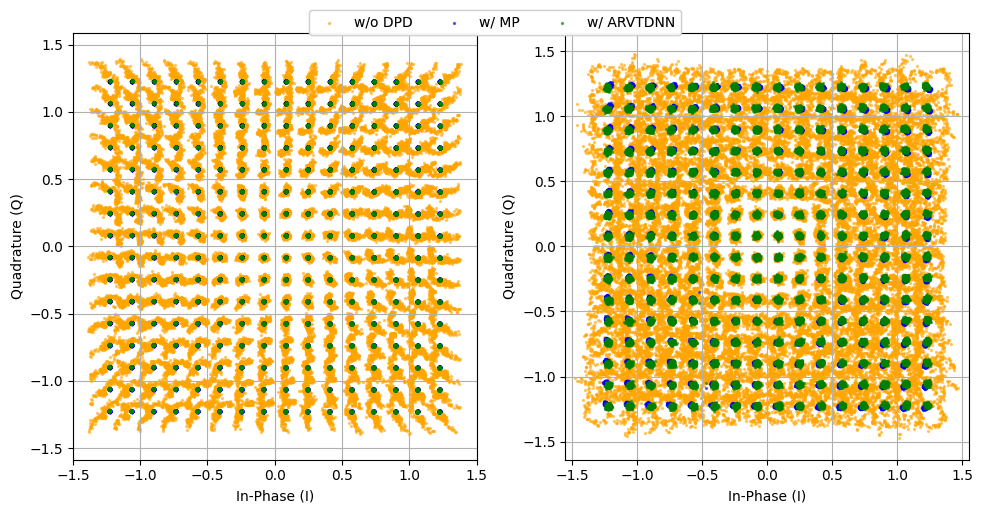

Calculating metrics for all zones and models...
Saved: Figures_Paper\metrics_table.csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import csv
import Metrics as met
from pathlib import Path

output_dir = Path("Figures_Paper")

# --- Matplotlib Publication Styling ---
plt.rcParams.update({'font.size': 10, 'lines.linewidth': 1.5})
plt.rcParams['svg.fonttype'] = 'none'  # Important for LaTeX/Inkscape compatibility

# --- Load Data ---
try:
    data_z1 = np.load("messdaten_zone1.npz")
    data_z2 = np.load("messdaten_zone2.npz")
except FileNotFoundError:
    print("Error: Please ensure 'messdaten_zone1.npz' and 'messdaten_zone2.npz' exist.")
    exit()

datasets = [("Nyquist Zone 1", data_z1), ("Nyquist Zone 2", data_z2)]

# Labels aligned with paper terminology
colors = {'x': 'black', 'y': 'orange', 'y_gmp': 'blue', 'y_arvtdnn': 'green'}
labels = {'x': 'Ideal', 'y': 'w/o DPD', 'y_gmp': 'w/ MP', 'y_arvtdnn': 'w/ ARVTDNN'}

# =================================================================
# 1. AM-AM and AM-PM Plot (2x2 Grid)
# =================================================================
fig_am, axes_am = plt.subplots(2, 2, figsize=(12, 10))

for row, (zone_name, data) in enumerate(datasets):
    x = data['x']
    signals = {'y': data['y'], 'y_gmp': data['y_gmp'], 'y_arvtdnn': data['y_arvtdnn']}

    ax_amam = axes_am[row, 0]
    ax_ampm = axes_am[row, 1]

    # Ideal reference line
    ax_amam.plot(
        [0, np.max(np.abs(x))], [0, np.max(np.abs(x))],
        color=colors['x'], linestyle='--', label=labels['x'], zorder=10
    )
    ax_ampm.axhline(0, color=colors['x'], linestyle='--', label=labels['x'], zorder=10)

    for key, sig in signals.items():
        ax_amam.scatter(
            np.abs(x), np.abs(sig),
            s=1, alpha=0.5, color=colors[key], label=labels[key], rasterized=True
        )
        phase_diff = np.angle(sig) - np.angle(x)
        phase_diff_deg = np.degrees((phase_diff + np.pi) % (2 * np.pi) - np.pi)
        ax_ampm.scatter(
            np.abs(x), phase_diff_deg,
            s=1, alpha=0.5, color=colors[key], label=labels[key], rasterized=True
        )

    # Titles use IEEE-standard hyphenated AM-AM / AM-PM
    #ax_amam.set_title(f"AM-AM - {zone_name}")
    ax_amam.set_xlabel(r"\$|x|\$")
    ax_amam.set_ylabel(r"\$|y|\$")
    ax_amam.grid(True)
    if row == 0:
        ax_amam.legend()

    #ax_ampm.set_title(f"AM-PM - {zone_name}")
    ax_ampm.set_xlabel(r"\$|x|\$")
    ax_ampm.set_ylabel("Phase Error (deg)")
    ax_ampm.set_ylim([-120, 120])
    ax_ampm.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "Plot_AM_AM_PM.svg", format="svg", dpi=300)
print("Saved: Plot_AM_AM_PM.svg")

# =================================================================
# 2. Power Spectral Density (Spectrum) Plot (2x1 Grid)
# =================================================================
fig_psd, axes_psd = plt.subplots(2, 1, figsize=(10, 8))

XLIM = 300  # MHz — adjust to hide spurs

for row, (zone_name, data) in enumerate(datasets):
    x = data['x']
    fs = float(data['fs'])
    signals_psd = {
        'y': data['y'],
        'y_gmp': data['y_gmp'],
        'y_arvtdnn': data['y_arvtdnn']
    }
    ax = axes_psd[row]

    # Compute ref_level from ideal signal without plotting it
    _, Pxx_ref = welch(x, fs, window='hann', nperseg=4096,
                       noverlap=2048, return_onesided=False)
    ref_level = np.max(10 * np.log10(np.fft.fftshift(Pxx_ref) + 1e-20))

    for key, sig in signals_psd.items():
        f, Pxx = welch(
            sig, fs, window='hann', nperseg=4096,
            noverlap=2048, return_onesided=False
        )
        f_shifted = np.fft.fftshift(f) / 1e6
        Pxx_dB = 10 * np.log10(np.fft.fftshift(Pxx) + 1e-20)
        ax.plot(
            f_shifted, Pxx_dB - ref_level,
            color=colors[key], label=labels[key], alpha=0.85
        )

    ax.legend(loc='upper right')
    ax.set_xlabel("Frequency Offset (MHz)")
    ax.set_ylabel("Normalized PSD (dB)")
    ax.set_ylim([-70, 5])
    ax.set_xlim([-XLIM, XLIM])
    ax.grid(True)

plt.tight_layout()
plt.savefig(output_dir / "Plot_Spectrum.svg", format="svg")
print("Saved: Plot_Spectrum.svg")
# =================================================================
# 3. Constellation (QAM) Diagram Plot (1x2 Grid)
# =================================================================
fig_iq, axes_iq = plt.subplots(1, 2, figsize=(10, 5))

for col, (zone_name, data) in enumerate(datasets):
    x = data['x']
    signals_iq = {
        'y': data['y'],
        'y_gmp': data['y_gmp'],
        'y_arvtdnn': data['y_arvtdnn']
    }
    ax = axes_iq[col]

    # FFT to frequency domain (subcarrier level)
    X_ideal = np.fft.fft(x)

    # FIX: Use absolute threshold (1e-6) to retain center/low-power bins
    # Previously used relative threshold (0.1 * max) which removed middle points
    threshold = 1e-6
    active_bins = np.abs(X_ideal) > threshold

    # QAM normalization factor
    X_qam_ideal = X_ideal[active_bins]
    scale_factor = np.mean(np.abs(X_qam_ideal))
    X_qam_ideal = X_qam_ideal / scale_factor

    # Plot received signals
    for key, sig in signals_iq.items():
        SIG_fft = np.fft.fft(sig)
        SIG_qam = SIG_fft[active_bins] / scale_factor
        ax.scatter(
            np.real(SIG_qam), np.imag(SIG_qam),
            s=2, alpha=0.5, color=colors[key], label=labels[key], rasterized=True
        )

    # Plot ideal constellation on top




    #ax.set_title(f"Constellation - {zone_name}")
    ax.set_xlabel("In-Phase (I)")
    ax.set_ylabel("Quadrature (Q)")
    ax.axis('equal')
    ax.grid(True)
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-1.5, 1.5])

    
    handles, label_list = ax.get_legend_handles_labels()
    fig_iq.legend(
        handles, label_list,
        loc='upper center',
        ncol=3,
        bbox_to_anchor=(0.5, 1.03),
        frameon=True
    )
plt.tight_layout()
#plt.savefig(output_dir / "Plot_Constellation.svg", format="svg", dpi=300)
print("Saved: Plot_Constellation.svg")

plt.show()

# =================================================================
# 4. Export Metrics Table as CSV
# =================================================================
csv_path = "Figures_Paper/metrics_table.csv"

rows = []
print("Calculating metrics for all zones and models...")

for zone_name, data in datasets:
    x = data['x']
    bw = float(data['bw'])
    fs = float(data['fs'])
    for sig_key, label in [('y', 'w/o DPD'), ('y_gmp', 'w/ MP'), ('y_arvtdnn', 'w/ ARVTDNN')]:
        if sig_key not in data:
            continue
        sig = data[sig_key]
        rows.append({
            'Zone':      zone_name,
            'Model':     label,
            'NMSE (dB)': f"{met.nmse(x, sig):.2f}",
            'ACLR (dBc)': f"{met.acpr(sig, bw=bw, fs=fs, offset=bw):.2f}",
            'EVM (%)':   f"{met.evm(x, sig):.2f}",
            'OOB (dB)':  f"{met.oob_nmse(x, sig, bw=bw, fs=fs):.2f}"
        })

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(
        f, fieldnames=['Zone', 'Model', 'NMSE (dB)', 'ACLR (dBc)', 'EVM (%)', 'OOB (dB)']
    )
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved: {csv_path}")